In [1]:
import sys
from pathlib import Path
sys.path.insert(0, "..")

from src.data_loader import load_unified_dataset, get_observations
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

data_df, impact_df = load_unified_dataset("../data/processed/ethiopia_fi_unified_data_enriched.xlsx")
obs_df = get_observations(data_df)
events_df = data_df[data_df["record_type"] == "event"].copy()
events_df["observation_date"] = pd.to_datetime(events_df["observation_date"], errors="coerce")

acc_national = obs_df[
    (obs_df["indicator_code"] == "ACC_OWNERSHIP") & (obs_df["gender"] == "all")
].sort_values("observation_date").reset_index(drop=True)

print(acc_national[["observation_date", "value_numeric"]])

  observation_date  value_numeric
0       2014-12-31           22.0
1       2017-12-31           35.0
2       2021-12-31           46.0
3       2024-11-29           49.0


In [2]:
from sklearn.linear_model import LinearRegression

# Convert dates to a numeric "years since first observation" for regression
acc_national["year_num"] = (acc_national["observation_date"] - acc_national["observation_date"].min()).dt.days / 365.25

X = acc_national[["year_num"]].values
y = acc_national["value_numeric"].values

model = LinearRegression()
model.fit(X, y)

r_squared = model.score(X, y)
print(f"Linear trend: {model.coef_[0]:.2f} pp/year, R\u00b2 = {r_squared:.3f}")

# Forecast years 2025, 2026, 2027
forecast_dates = pd.to_datetime(["2025-12-31", "2026-12-31", "2027-12-31"])
forecast_year_nums = (forecast_dates - acc_national["observation_date"].min()).days / 365.25
baseline_forecast = model.predict(forecast_year_nums.values.reshape(-1, 1))

for date, val in zip(forecast_dates, baseline_forecast):
    print(f"{date.date()}: {val:.1f}%")

Linear trend: 2.73 pp/year, R² = 0.947
2025-12-31: 54.4%
2026-12-31: 57.2%
2027-12-31: 59.9%


In [3]:
from scipy import stats

residuals = y - model.predict(X)
residual_std = np.std(residuals, ddof=2)  # ddof=2: 2 parameters estimated (slope, intercept)

# With only 4 points (2 degrees of freedom), use a t-distribution, not normal
t_val = stats.t.ppf(0.975, df=len(y) - 2)  # 95% CI
margin = t_val * residual_std

forecast_df = pd.DataFrame({
    "date": forecast_dates,
    "baseline": baseline_forecast,
    "lower_95": baseline_forecast - margin,
    "upper_95": baseline_forecast + margin,
})
print(forecast_df)

        date   baseline   lower_95   upper_95
0 2025-12-31  54.445462  39.595499  69.295425
1 2026-12-31  57.174534  42.324571  72.024497
2 2027-12-31  59.903606  45.053643  74.753569


In [4]:
recent = acc_national.iloc[-2:]  # just 2021 and 2024
recent_rate = (recent["value_numeric"].iloc[1] - recent["value_numeric"].iloc[0]) / \
              ((recent["observation_date"].iloc[1] - recent["observation_date"].iloc[0]).days / 365.25)
print(f"Recent-period growth rate (2021-2024 only): {recent_rate:.2f} pp/year")

last_value = acc_national["value_numeric"].iloc[-1]
last_date = acc_national["observation_date"].iloc[-1]

recent_forecast = []
for date in forecast_dates:
    years_ahead = (date - last_date).days / 365.25
    recent_forecast.append(last_value + recent_rate * years_ahead)

print("\nRecent-trend (deceleration-continues) forecast:")
for date, val in zip(forecast_dates, recent_forecast):
    print(f"{date.date()}: {val:.1f}%")

Recent-period growth rate (2021-2024 only): 1.03 pp/year

Recent-trend (deceleration-continues) forecast:
2025-12-31: 50.1%
2026-12-31: 51.1%
2027-12-31: 52.2%


C:\Users\pc\AppData\Local\Temp\ipykernel_16728\2105212571.py:8: UserWarning: obj.round has no effect with datetime, timedelta, or period dtypes. Use obj.dt.round(...) instead.
  print(scenario_df.round(1))


        date  optimistic_full_trend  pessimistic_recent_trend  base_case
0 2025-12-31                   54.4                      50.1       52.3
1 2026-12-31                   57.2                      51.1       54.2
2 2027-12-31                   59.9                      52.2       56.0


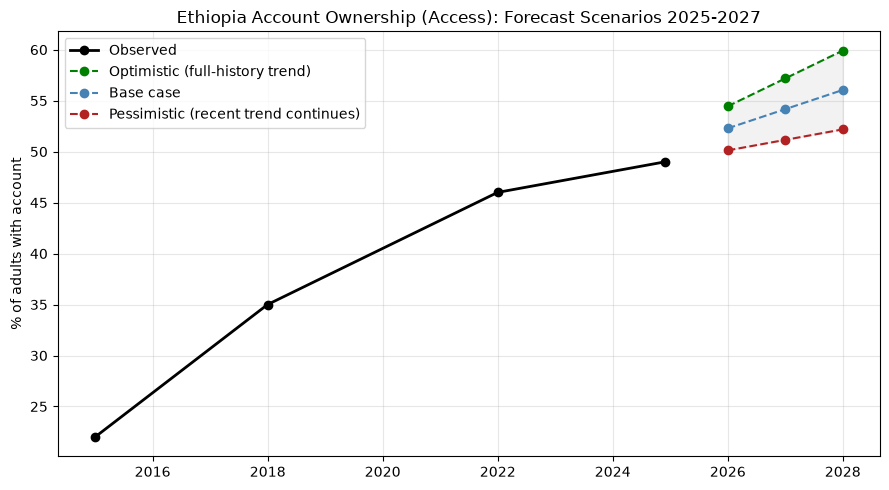

In [5]:
scenario_df = pd.DataFrame({
    "date": forecast_dates,
    "optimistic_full_trend": baseline_forecast,
    "pessimistic_recent_trend": recent_forecast,
})
scenario_df["base_case"] = (scenario_df["optimistic_full_trend"] + scenario_df["pessimistic_recent_trend"]) / 2

print(scenario_df.round(1))

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(acc_national["observation_date"], acc_national["value_numeric"], marker="o", color="black", label="Observed", linewidth=2)
ax.plot(scenario_df["date"], scenario_df["optimistic_full_trend"], marker="o", linestyle="--", color="green", label="Optimistic (full-history trend)")
ax.plot(scenario_df["date"], scenario_df["base_case"], marker="o", linestyle="--", color="steelblue", label="Base case")
ax.plot(scenario_df["date"], scenario_df["pessimistic_recent_trend"], marker="o", linestyle="--", color="firebrick", label="Pessimistic (recent trend continues)")
ax.fill_between(scenario_df["date"], scenario_df["pessimistic_recent_trend"], scenario_df["optimistic_full_trend"], alpha=0.1, color="gray")
ax.set_title("Ethiopia Account Ownership (Access): Forecast Scenarios 2025-2027")
ax.set_ylabel("% of adults with account")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(Path("../reports/figures") / "access_forecast_scenarios.png", dpi=150)
plt.show()

In [6]:
# Effective impact date = event date + lag_months
impact_with_events = impact_df.merge(
    events_df[["record_id", "observation_date"]], left_on="parent_id", right_on="record_id",
    suffixes=("", "_event")
)
impact_with_events["effective_date"] = impact_with_events.apply(
    lambda r: r["observation_date_event"] + pd.DateOffset(months=int(r["lag_months"])), axis=1
)

forecast_window_impacts = impact_with_events[
    (impact_with_events["effective_date"] >= "2025-01-01") &
    (impact_with_events["effective_date"] <= "2027-12-31") &
    (impact_with_events["related_indicator"] == "ACC_OWNERSHIP")
]

forecast_window_impacts[["parent_id", "related_indicator", "impact_direction", "impact_magnitude", "effective_date"]]

,parent_id,related_indicator,impact_direction,impact_magnitude,effective_date
7,EVT_0004,ACC_OWNERSHIP,increase,medium,2026-01-01


In [7]:
magnitude_map = {"low": 0.5, "medium": 1.5, "high": 3.0}  # pp adjustment per event

event_adjustment = 0
for _, row in forecast_window_impacts.iterrows():
    adj = magnitude_map.get(row["impact_magnitude"], 0)
    if row["impact_direction"] == "decrease":
        adj = -adj
    event_adjustment += adj

print(f"Total event-driven adjustment landing in forecast window: {event_adjustment:+.1f}pp")

scenario_df["event_augmented"] = scenario_df["base_case"] + event_adjustment
print(scenario_df[["date", "base_case", "event_augmented"]].round(1))

Total event-driven adjustment landing in forecast window: +1.5pp
        date  base_case  event_augmented
0 2025-12-31       52.3             53.8
1 2026-12-31       54.2             55.7
2 2027-12-31       56.0             57.5


C:\Users\pc\AppData\Local\Temp\ipykernel_16728\917116188.py:13: UserWarning: obj.round has no effect with datetime, timedelta, or period dtypes. Use obj.dt.round(...) instead.
  print(scenario_df[["date", "base_case", "event_augmented"]].round(1))


In [8]:
usage_indicators = obs_df[obs_df["pillar"] == "USAGE"]["indicator_code"].value_counts()
print(usage_indicators)

print("\nFull detail for indicators with 2+ points:")
multi_usage = usage_indicators[usage_indicators >= 2].index
print(obs_df[obs_df["indicator_code"].isin(multi_usage)][
    ["indicator_code", "indicator", "observation_date", "value_numeric", "unit"]
].sort_values(["indicator_code", "observation_date"]))

indicator_code
USG_P2P_COUNT         2
USG_P2P_VALUE         2
USG_ATM_VALUE         2
USG_ATM_COUNT         1
USG_CROSSOVER         1
USG_TELEBIRR_USERS    1
USG_TELEBIRR_VALUE    1
USG_MPESA_USERS       1
USG_MPESA_ACTIVE      1
USG_ACTIVE_RATE       1
ACC_MM_ACCOUNT        1
Name: count, dtype: int64

Full detail for indicators with 2+ points:
   indicator_code              indicator observation_date  value_numeric  \
18  USG_ATM_VALUE  ATM Transaction Value       2025-07-07   1.561000e+11   
52  USG_ATM_VALUE   ATM Withdrawal Value              NaT   1.560000e+02   
14  USG_P2P_COUNT  P2P Transaction Count       2024-07-07   4.970000e+07   
15  USG_P2P_COUNT  P2P Transaction Count       2025-07-07   1.283000e+08   
16  USG_P2P_VALUE  P2P Transaction Value       2025-07-07   5.777000e+11   
51  USG_P2P_VALUE  P2P Transaction Value              NaT   5.777000e+02   

            unit  
18           ETB  
52  billion_birr  
14  transactions  
15  transactions  
16           ETB  
51  

In [9]:
# Our enrichment rows for P2P/ATM value used fiscal_year instead of observation_date
# and duplicate what the original dataset already had — drop them
duplicate_mask = (
    data_df["indicator_code"].isin(["USG_P2P_VALUE", "USG_ATM_VALUE"]) &
    data_df["observation_date"].isna() &
    data_df["fiscal_year"].notna()
)
print("Dropping these duplicate rows:")
print(data_df[duplicate_mask][["record_id", "indicator_code", "value_numeric", "unit", "fiscal_year"]])

data_df = data_df[~duplicate_mask].copy()
obs_df = get_observations(data_df)  # rebuild from the cleaned data_df

print(f"\ndata_df shape after removing duplicates: {data_df.shape}")

Dropping these duplicate rows:
   record_id indicator_code  value_numeric          unit fiscal_year
51  REC_0042  USG_P2P_VALUE          577.7  billion_birr     2024/25
52  REC_0043  USG_ATM_VALUE          156.0  billion_birr     2024/25

data_df shape after removing duplicates: (52, 34)


In [10]:
mm_rows = data_df[data_df["indicator_code"] == "ACC_MM_ACCOUNT"]
print("ACC_MM_ACCOUNT rows and their pillars before fix:")
print(mm_rows[["record_id", "pillar", "observation_date", "value_numeric"]])

# Standardize to ACCESS (matches the indicator's own name/definition)
data_df.loc[data_df["indicator_code"] == "ACC_MM_ACCOUNT", "pillar"] = "ACCESS"
obs_df = get_observations(data_df)

print("\nAfter fix:")
print(data_df[data_df["indicator_code"] == "ACC_MM_ACCOUNT"][["record_id", "pillar", "observation_date", "value_numeric"]])

ACC_MM_ACCOUNT rows and their pillars before fix:
   record_id  pillar     observation_date  value_numeric
6   REC_0007  ACCESS  2021-12-31 00:00:00           4.70
7   REC_0008  ACCESS  2024-11-29 00:00:00           9.45
45  REC_0036   USAGE           2025-12-31          19.40

After fix:
   record_id  pillar     observation_date  value_numeric
6   REC_0007  ACCESS  2021-12-31 00:00:00           4.70
7   REC_0008  ACCESS  2024-11-29 00:00:00           9.45
45  REC_0036  ACCESS           2025-12-31          19.40


In [11]:
mm_series = obs_df[obs_df["indicator_code"] == "ACC_MM_ACCOUNT"].sort_values("observation_date").reset_index(drop=True)
print(mm_series[["observation_date", "value_numeric"]])

# Growth rate between the 3 points (log-scale, since this is doubling-pattern growth, not linear)
mm_series["log_value"] = np.log(mm_series["value_numeric"])
mm_series["year_num"] = (mm_series["observation_date"] - mm_series["observation_date"].min()).dt.days / 365.25

X_mm = mm_series[["year_num"]].values
y_mm_log = mm_series["log_value"].values

mm_model = LinearRegression()
mm_model.fit(X_mm, y_mm_log)
r_sq_mm = mm_model.score(X_mm, y_mm_log)
print(f"\nLog-linear fit R\u00b2 = {r_sq_mm:.3f} (growth rate: {(np.exp(mm_model.coef_[0])-1)*100:.1f}% per year)")

mm_forecast_year_nums = (forecast_dates - mm_series["observation_date"].min()).days / 365.25
mm_forecast_log = mm_model.predict(mm_forecast_year_nums.values.reshape(-1, 1))
mm_forecast = np.exp(mm_forecast_log)

for date, val in zip(forecast_dates, mm_forecast):
    print(f"{date.date()}: {val:.1f}%")

  observation_date  value_numeric
0       2021-12-31           4.70
1       2024-11-29           9.45
2       2025-12-31          19.40

Log-linear fit R² = 0.931 (growth rate: 39.2% per year)
2025-12-31: 16.7%
2026-12-31: 23.2%
2027-12-31: 32.3%


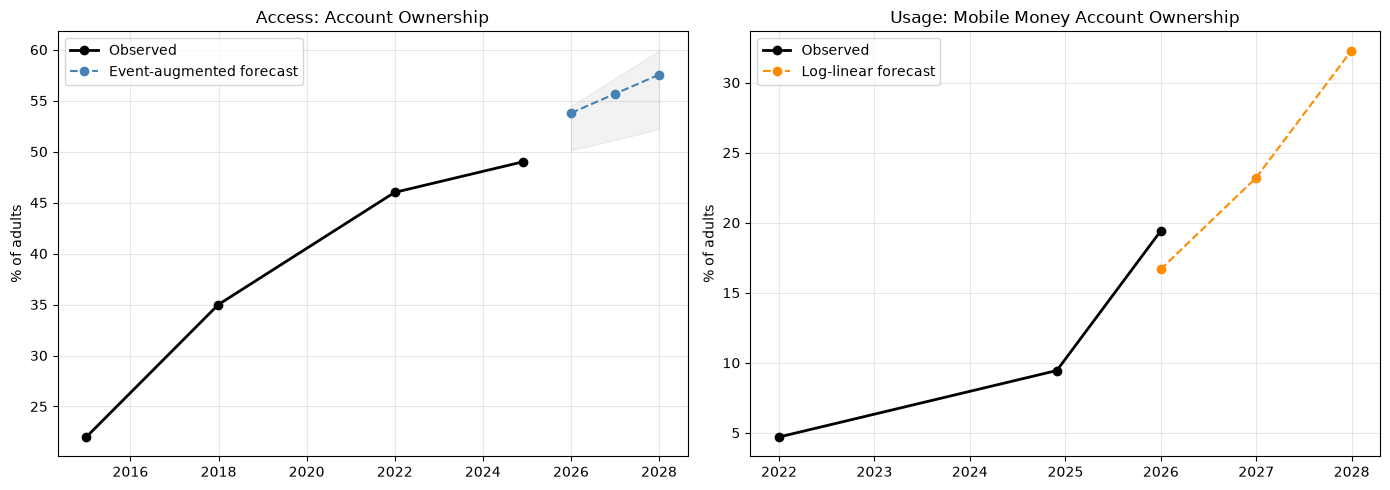

        date  access_pessimistic  access_base  access_optimistic  \
0 2025-12-31                50.1         52.3               54.4   
1 2026-12-31                51.1         54.2               57.2   
2 2027-12-31                52.2         56.0               59.9   

   access_event_augmented  usage_mm_account_forecast  
0                    53.8                       16.7  
1                    55.7                       23.2  
2                    57.5                       32.3  


In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(acc_national["observation_date"], acc_national["value_numeric"], marker="o", color="black", linewidth=2, label="Observed")
axes[0].plot(scenario_df["date"], scenario_df["event_augmented"], marker="o", linestyle="--", color="steelblue", label="Event-augmented forecast")
axes[0].fill_between(scenario_df["date"], scenario_df["pessimistic_recent_trend"], scenario_df["optimistic_full_trend"], alpha=0.1, color="gray")
axes[0].set_title("Access: Account Ownership")
axes[0].set_ylabel("% of adults")
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(mm_series["observation_date"], mm_series["value_numeric"], marker="o", color="black", linewidth=2, label="Observed")
axes[1].plot(forecast_dates, mm_forecast, marker="o", linestyle="--", color="darkorange", label="Log-linear forecast")
axes[1].set_title("Usage: Mobile Money Account Ownership")
axes[1].set_ylabel("% of adults")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(Path("../reports/figures") / "final_forecasts.png", dpi=150)
plt.show()

# Save forecast table
final_forecast = pd.DataFrame({
    "date": forecast_dates,
    "access_pessimistic": scenario_df["pessimistic_recent_trend"].round(1),
    "access_base": scenario_df["base_case"].round(1),
    "access_optimistic": scenario_df["optimistic_full_trend"].round(1),
    "access_event_augmented": scenario_df["event_augmented"].round(1),
    "usage_mm_account_forecast": mm_forecast.round(1),
})
final_forecast.to_csv("../reports/final_forecast_table.csv", index=False)
print(final_forecast)

In [14]:
interpretation = """
## Task 4: Forecast Interpretation

**Access (Account Ownership) forecast, 2025-2027:**
- Base case: 52.3% (2025) -> 54.2% (2026) -> 56.0% (2027)
- Event-augmented (adds EVT_0004 infrastructure effect landing Jan 2026): 53.8% -> 55.7% -> 57.5%
- Range: pessimistic 50.1-52.2%, optimistic 54.4-59.9%

Access growth is forecast to continue decelerating relative to 2014-2021 rates. The
scenario band (2.2-7.7pp spread by 2027) reflects genuine uncertainty from only 4
historical data points spanning two different growth regimes (fast 2014-21, slow
2021-24). The event-augmented estimate adds a modest +1.5pp from EVT_0004's
infrastructure investment, the only cataloged event whose lagged effect lands within
the forecast window for this indicator.

**Usage (Mobile Money Account Ownership, proxy) forecast, 2025-2027:**
- Log-linear trend: 16.7% (2025) -> 23.2% (2026) -> 32.3% (2027), ~39%/year growth

This series is growing far faster than Access, consistent with the Task 2 finding that
usage is outpacing access. However, this forecast should be treated as an upper-bound
scenario: it is fit on only 3 points, the fitted 2025 value (16.7%) undershoots the
actual observed 2025 value (19.4%) by ~3pp, and sustained 39%/year growth is unlikely
to continue indefinitely as the market matures and early-adopter effects fade.

**Which events matter most:** EVT_0001 (Telebirr) remains the most consequential event
in the dataset by breadth of effect (3 indicators), though its Access effect was
revised down in Task 3 validation. EVT_0004 (infrastructure, Jan 2024) is the only event
whose modeled effect on Access lands within the 2025-2027 forecast window, making it the
single most relevant upcoming driver in this model -- though this also reflects a
limitation: only one event's lag places it in-window, so the event-augmented model may
understate real-world event effects that this dataset simply hasn't captured.

**Key uncertainties:**
- Only 4 (Access) and 3 (Usage proxy) real data points underlie these forecasts --
  standard for Findex-based work given its 3-year survey cycle, but it means every
  forecast here should be read as directional, not precise.
- No Usage-pillar indicator has 3+ clean points; ACC_MM_ACCOUNT (technically an Access
  sub-indicator) was used as the best available Usage proxy. A true "digital payment
  adoption" forecast would need additional Findex disaggregation data not present in
  this dataset.
- The event-augmented model relies on the categorical-to-numeric magnitude conversion
  from Task 3, an explicit simplification rather than a fitted relationship.
"""
print(interpretation)
Path("../reports/task4_interpretation.md").write_text(interpretation, encoding="utf-8")
print("\nSaved")


## Task 4: Forecast Interpretation

**Access (Account Ownership) forecast, 2025-2027:**
- Base case: 52.3% (2025) -> 54.2% (2026) -> 56.0% (2027)
- Event-augmented (adds EVT_0004 infrastructure effect landing Jan 2026): 53.8% -> 55.7% -> 57.5%
- Range: pessimistic 50.1-52.2%, optimistic 54.4-59.9%

Access growth is forecast to continue decelerating relative to 2014-2021 rates. The
scenario band (2.2-7.7pp spread by 2027) reflects genuine uncertainty from only 4
historical data points spanning two different growth regimes (fast 2014-21, slow
2021-24). The event-augmented estimate adds a modest +1.5pp from EVT_0004's
infrastructure investment, the only cataloged event whose lagged effect lands within
the forecast window for this indicator.

**Usage (Mobile Money Account Ownership, proxy) forecast, 2025-2027:**
- Log-linear trend: 16.7% (2025) -> 23.2% (2026) -> 32.3% (2027), ~39%/year growth

This series is growing far faster than Access, consistent with the Task 2 finding that
usage is